In [ ]:

!git clone https://github.com/Felix982/XAI-project.git
#!git pull origin main

%cd /content/XAI-project

/content/XAI-project
Cloning into 'XAI-project'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 70 (delta 21), reused 59 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 142.08 KiB | 20.30 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [7]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.6 MB/s eta 0:00:00


In [3]:
import os
import sys

PROJECT_ROOT = "/content/XAI-project"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [22]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [23]:
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/xai_project_outputs"

In [8]:
import training.train_diffusion as train_diffusion_mod

In [9]:
cfg = train_diffusion_mod.DiffusionTrainConfig(
    data_root="./data",
    image_size=32,
    num_channels=3,
    num_classes=2,
    batch_size=64,
    num_workers=2,
    lr=1e-4,
    max_epochs=10,
    output_dir="./outputs/diffusion",
)

results = train_diffusion_mod.train_diffusion(cfg)
results

100%|██████████| 4.17M/4.17M [00:01<00:00, 2.66MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Epoch 001 | train_loss=0.011148 | val_loss=0.011537
Epoch 002 | train_loss=0.010700 | val_loss=0.011069
Epoch 003 | train_loss=0.010437 | val_loss=0.010765
Epoch 004 | train_loss=0.009849 | val_loss=0.009727
Epoch 005 | train_loss=0.009924 | val_loss=0.009118
Epoch 006 | train_loss=0.010536 | val_loss=0.010225
Epoch 007 | train_loss=0.010050 | val_loss=0.009352
Epoch 008 | train_loss=0.010281 | val_loss=0.010616
Epoch 009 | train_loss=0.009841 | val_loss=0.008882
Epoch 010 | train_loss=0.009193 | val_loss=0.010510


{'best_epoch': 9,
 'best_val_loss': 0.008881668741494873,
 'best_model_path': './outputs/diffusion/diffusion_best.pt',
 'last_model_path': './outputs/diffusion/diffusion_last.pt',
 'history': [{'epoch': 1,
   'train_loss': 0.01114788711840127,
   'val_loss': 0.011537193861000865},
  {'epoch': 2,
   'train_loss': 0.01069989223025277,
   'val_loss': 0.011069438775702743},
  {'epoch': 3,
   'train_loss': 0.010436644567178282,
   'val_loss': 0.010765481271020328},
  {'epoch': 4,
   'train_loss': 0.009848973821427676,
   'val_loss': 0.009727082405424187},
  {'epoch': 5,
   'train_loss': 0.009924397382888382,
   'val_loss': 0.009118144606588451},
  {'epoch': 6,
   'train_loss': 0.010535599482653247,
   'val_loss': 0.010225032527312522},
  {'epoch': 7,
   'train_loss': 0.010050001287533757,
   'val_loss': 0.009351785049439613},
  {'epoch': 8,
   'train_loss': 0.01028050904652023,
   'val_loss': 0.010616395419875857},
  {'epoch': 9,
   'train_loss': 0.009840921134851752,
   'val_loss': 0.00888

In [ ]:
!zip -r classifier_outputs.zip ./outputs/classifier
!zip -r diffusion_outputs.zip ./outputs/diffusion
!zip -r sample_outputs.zip ./outputs/samples

In [ ]:
from google.colab import files

files.download("classifier_outputs.zip")
files.download("diffusion_outputs.zip")
files.download("sample_outputs.zip")

In [4]:
import sampling.sample_diffusion as sample_mod

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
#sample class 1
cfg = sample_mod.SampleConfig(
    checkpoint_path="./outputs/diffusion/diffusion_best.pt",
    output_dir="./outputs/samples/class_0",
    class_label=0,
    batch_size=8,
    num_inference_steps=50,
)

paths = sample_mod.generate_and_save_samples(cfg)
paths[:3]

['./outputs/samples/class_0/samples_class_0_grid.png',
 './outputs/samples/class_0/class_0_sample_000.png',
 './outputs/samples/class_0/class_0_sample_001.png']

In [ ]:
#class 2
cfg = sample_mod.SampleConfig(
    checkpoint_path="./outputs/diffusion/diffusion_best.pt",
    output_dir="./outputs/samples/class_1",
    class_label=1,
    batch_size=8,
    num_inference_steps=50,
)

paths = sample_mod.generate_and_save_samples(cfg)
paths[:3]

['./outputs/samples/class_1/samples_class_1_grid.png',
 './outputs/samples/class_1/class_1_sample_000.png',
 './outputs/samples/class_1/class_1_sample_001.png']

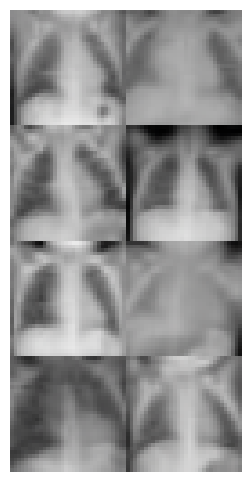

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("./outputs/samples/class_0/samples_class_0_grid.png")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

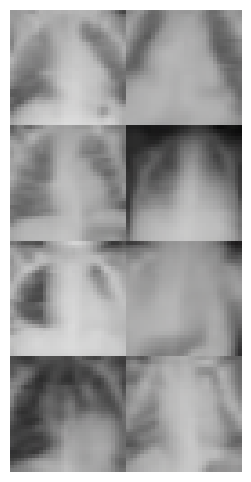

In [13]:
img = Image.open("./outputs/samples/class_1/samples_class_1_grid.png")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

Fine tuning seems ok !


In [14]:
from google.colab import files
files.download("./outputs/samples/class_0/samples_class_0_grid.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
files.download("./outputs/samples/class_1/samples_class_1_grid.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Testing class accuracy

In [16]:
%cd /content/XAI-project
!git pull origin main

/content/XAI-project
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 5.03 KiB | 367.00 KiB/s, done.
From https://github.com/Felix982/XAI-project
 * branch            main       -> FETCH_HEAD
   c289c17..7847570  main       -> origin/main
Updating c289c17..7847570
Fast-forward
 .DS_Store                                      | Bin 0 -> 6148 bytes
 evaluation/__init__.py                         |   0
 evaluation/evaluate_generated_samples.py       | 151 ++++++++++++++
 notebooks/01_train_classifier.ipynb            | 259 +++++++++----------------
 notebooks/02_pretrained_diffusion_sanity.ipynb |  12 --
 5 files changed, 248 insertions(+), 174 deletions(-)
 create mode 100644 .DS_Store
 create mode 100644 evaluation/__init__.py
 create mode 100644 evaluation/evaluate_generated_samples.py


In [17]:
import sys

PROJECT_ROOT = "/content/XAI-project"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [18]:
import evaluation.evaluate_generated_samples as eval_gen_mod

In [20]:
cfg = eval_gen_mod.GeneratedSampleEvalConfig(
    diffusion_checkpoint_path="./outputs/diffusion/diffusion_best.pt",
    classifier_checkpoint_path="./outputs/classifier/classifier_best.pt",
    output_dir="./outputs/generated_eval",
    num_samples_per_class=64,
    num_inference_steps=50,
)

summary = eval_gen_mod.evaluate_generated_samples(cfg)
summary

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


class=0 | consistency=0.7812 | mean_target_prob=0.7761
class=1 | consistency=1.0000 | mean_target_prob=0.9749


{'config': {'diffusion_checkpoint_path': './outputs/diffusion/diffusion_best.pt',
  'pretrained_repo_id': 'google/ddpm-cifar10-32',
  'classifier_checkpoint_path': './outputs/classifier/classifier_best.pt',
  'image_size': 32,
  'num_channels': 3,
  'num_classes': 2,
  'num_samples_per_class': 64,
  'num_inference_steps': 50,
  'num_train_timesteps': 1000,
  'seed': 42,
  'classifier_base_channels': 32,
  'classifier_dropout': 0.1,
  'output_dir': './outputs/generated_eval',
  'device': 'cuda'},
 'per_class': {'class_0': {'target_class': 0,
   'num_samples': 64,
   'target_consistency': 0.78125,
   'mean_target_probability': 0.7761181592941284,
   'mean_prob_class1': 0.22388184070587158},
  'class_1': {'target_class': 1,
   'num_samples': 64,
   'target_consistency': 1.0,
   'mean_target_probability': 0.9748595356941223,
   'mean_prob_class1': 0.9748595356941223}},
 'average_target_consistency': 0.890625}

In [25]:
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/xai_project_outputs"
CLASSIFIER_DIR = f"{DRIVE_PROJECT_DIR}/classifier"
DIFFUSION_DIR = f"{DRIVE_PROJECT_DIR}/diffusion"
SAMPLES_DIR = f"{DRIVE_PROJECT_DIR}/samples"

import os
os.makedirs(CLASSIFIER_DIR, exist_ok=True)
os.makedirs(DIFFUSION_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

In [26]:
!cp ./outputs/diffusion/diffusion_best.pt "/content/drive/MyDrive/xai_project_outputs/diffusion/"
!cp ./outputs/diffusion/diffusion_last.pt "/content/drive/MyDrive/xai_project_outputs/diffusion/"
!cp ./outputs/diffusion/history.json "/content/drive/MyDrive/xai_project_outputs/diffusion/"
!cp ./outputs/diffusion/final_results.json "/content/drive/MyDrive/xai_project_outputs/diffusion/"
!cp ./outputs/diffusion/pretrained_load_info.json "/content/drive/MyDrive/xai_project_outputs/diffusion/"

In [27]:
!cp ./outputs/classifier/classifier_best.pt "/content/drive/MyDrive/xai_project_outputs/classifier/"
!cp ./outputs/classifier/classifier_last.pt "/content/drive/MyDrive/xai_project_outputs/classifier/"
!cp ./outputs/classifier/history.json "/content/drive/MyDrive/xai_project_outputs/classifier/"
!cp ./outputs/classifier/final_results.json "/content/drive/MyDrive/xai_project_outputs/classifier/"